# K4As4Pt2：拟合、热导率与温度相关声子谱

用配套位移与力样本恢复 FC2–FC4，先计算固定模型的 RTA 热导率，再用四阶环近似 SCPH 求温度相关的有效 FC2 和声子谱。

结构和 ALAMODE 位移样本在 `data/k4as4pt2`，力已经存入训练文件。无需在本教程中重新运行 ALAMODE；环境准备见[教程总览](index.md)。

## 1. 读取参考结构

原胞有 10 个原子，训练超胞是 $2\times2\times3$、120 原子。样本中的位移以这份理想超胞为参考，不能随意改原子排序或换一个热运动构型作零点。

换材料时，首先替换结构与带力样本，再调整下面的局域模型范围。

In [1]:
from pathlib import Path
import logging
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read, iread
from ase.units import Bohr
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem
from mlfcs.phonon import Harmonic, SCPH

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/k4as4pt2")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-k4-"))
primitive = read(DATA / "primitive.vasp")
supercell = read(DATA / "supercell.vasp")
print(f"原胞：{len(primitive)} 原子；超胞：{len(supercell)} 原子")

原胞：10 原子；超胞：120 原子


## 2. 选择二阶到四阶的模型

沿用数据案例的截断：FC2 为 6.5 Å、FC3 为 12 Bohr、FC4 为 8 Bohr。ASE 的 `Bohr` 将后两项换成 Å，传给 MLFCS 的半径具有同一单位。

最大体阶为 2、3、3，因此四阶允许重复原子指标，但最多涉及三个不同位置。这使教学计算保持可控，同时也是需要检查的模型近似。

`asr=True` 既约束这次拟合，也为后面的 SCPH 二阶更新准备平移约束坐标。`ClusterMap` 推断超胞矩阵，先检查可辨识性再收集力。

In [2]:
cutoffs = {2: 6.5, 3: 12 * Bohr, 4: 8 * Bohr}
space = ClusterSpace(primitive, cutoffs=cutoffs,
                     max_body_orders={2: 2, 3: 3, 4: 3}, asr=True)
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
for order, cutoff in cutoffs.items():
    print(f"FC{order} 截断：{cutoff:.3f} Å")
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

FC2 截断：6.500 Å
FC3 截断：6.350 Å
FC4 截断：4.233 Å
物理参数：6849；ASR 自由参数：4784


## 3. 收集已有力并联合拟合

`ForceDataset` 读取每帧存储的力，不调用 calculator。`representation="normal"` 累积正规方程，避免保存所有力观测对应的设计矩阵。

拟合联合求解三种阶数。使用默认容差，将迭代上限提高到 10000，为参数较多的模型预留空间。训练误差反映模型对这些样本的解释程度，仍需独立数据验证。

In [3]:
dataset = ForceDataset(mapping, iread(DATA / "train.extxyz", index=":"))
print(f"训练样本：{len(dataset.forces)} 帧")
system = FitSystem(dataset, representation="normal")
model = system.solve(maxiter=10_000)
print(f"力 RMSE：{system.rmse(model):.5f} eV/Å")
print(f"力相对误差：{system.relative_error(model):.3%}")

训练样本：250 帧


力 RMSE：0.01833 eV/Å
力相对误差：6.481%


## 4. 导出固定模型的 FC2 与 FC3

先用拟合得到的 FC2、FC3 做三声子 RTA。FC4 不直接进入这项散射计算，下一步才用于 SCPH。

HDF5 文件写到临时目录。下面以训练超胞作为 phono3py 输入晶胞、超胞矩阵取单位阵，保持导出排序；原胞变换使用 MLFCS 超胞矩阵的逆的转置，以符合 Phonopy 的列向量约定，首指标按 `p2s_map` 选出原胞代表原子。换自己的数据时，不应省略这项顺序对应。

In [4]:
fc2_file = SCRATCH / "fc2.hdf5"
fc3_file = SCRATCH / "fc3.hdf5"
model.write(fc2_file, mapping, format="phonopy", storage="hdf5", order=2)
model.write(fc3_file, mapping, format="phono3py", storage="hdf5", order=3)
from phono3py import Phono3py
from phono3py.file_IO import read_fc2_from_hdf5, read_fc3_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

unitcell = PhonopyAtoms(
    symbols=supercell.get_chemical_symbols(), cell=supercell.cell.array,
    scaled_positions=supercell.get_scaled_positions(), masses=supercell.get_masses(),
)
ph3 = Phono3py(unitcell, np.eye(3, dtype=int),
               primitive_matrix=np.linalg.inv(mapping.supercell_matrix).T, log_level=0)
p2s = ph3.phonon_primitive.p2s_map
ph3.fc2 = read_fc2_from_hdf5(str(fc2_file))[p2s]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_file))[p2s]

## 5. 计算 RTA 热导率

在 $10\times10\times10$ q 网格上计算 300–900 K 的温度序列，加入天然同位素散射。`write_kappa=False` 将结果留在 notebook 中。

这一步使用固定的拟合模型，没有加入后面 SCPH 得到的温度重整化，也没有计算四声子散射。网格与模型截断仍需收敛检查，表格不能直接当作实验复现。

In [5]:
TEMPERATURES = tuple(range(300, 901, 100))
ph3.mesh_numbers = (10, 10, 10)
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(temperatures=TEMPERATURES, is_isotope=True,
                            write_kappa=False, log_level=0)
kappa = ph3.thermal_conductivity.kappa.reshape(-1, 6)
print("T (K)    κxx       κyy       κzz   [W/(m·K)]")
for temperature, values in zip(TEMPERATURES, kappa):
    print(f"{temperature:5g}  {values[0]:8.3f}  {values[1]:8.3f}  {values[2]:8.3f}")

T (K)    κxx       κyy       κzz   [W/(m·K)]
  300     0.292     0.370     0.423
  400     0.219     0.277     0.317
  500     0.175     0.221     0.254
  600     0.146     0.184     0.211
  700     0.125     0.158     0.181
  800     0.109     0.138     0.158
  900     0.097     0.122     0.141


## 6. 用 FC4 更新有限温度的有效 FC2

SCPH 从当前 FC2 计算位移协方差，再与 FC4 收缩得到二阶修正，并自洽迭代。这里采用量子统计，因此 0 K 也保留零点运动；FC3 不参与四阶环近似。

用 $4\times4\times6$ 网格采样协方差。它与前面 RTA 网格用途不同，应分别做收敛检查。已启用 ASR 的模型会把二阶更新目标投影回平移约束空间，不需要追加 ASR 后处理。

选 0、300、600、900 K 四个温度，便于在一张图中比较。`run_many` 接收递增温度，内部从高温降温求解，只有收敛解才用于下一温度的初值。

In [6]:
scph = SCPH(model, mesh=(4, 4, 6), statistics="quantum")
scph_temperatures = (0, 300, 600, 900)

混合系数 0.2 表示每次更新只取目标参数变化的五分之一，帮助稳定迭代。频率变化容差取 $10^{-5}$ THz，适合教学绘图；需要更精确结果时应收紧容差并检查网格。

最多 200 次迭代。返回结果不代表一定收敛，必须查看 `converged`；数值收敛与是否存在虚频也是两项独立判断。最小物理频率排除了 Γ 点的三个刚性平移模式。

In [7]:
results = scph.run_many(scph_temperatures, mixing=0.2, tolerance=1e-5, max_iterations=200)
for result in results:
    print(f"{result.temperature:4g} K：{result.iterations:3d} 次迭代，"
          f"收敛={result.converged}，最小物理频率={result.minimum_mode_thz:.4f} THz")
if not all(result.converged for result in results):
    raise RuntimeError("SCPH 未全部收敛：请检查迭代历史，再调整混合、网格或迭代上限")

   0 K： 35 次迭代，收敛=True，最小物理频率=0.2617 THz
 300 K： 31 次迭代，收敛=True，最小物理频率=0.3123 THz
 600 K： 29 次迭代，收敛=True，最小物理频率=0.3445 THz
 900 K： 33 次迭代，收敛=True，最小物理频率=0.3681 THz


## 7. 比较温度相关声子谱

每个结果的 `fc2` 是该温度下的有效二阶模型。沿同一个 ASE 路径计算，才能直接比较频率变化；200 个 q 点是绘图采样。

四种温度叠加在一张图上。SCPH 可能硬化或软化某些模式，不预设所有模式随温度升高而变硬。

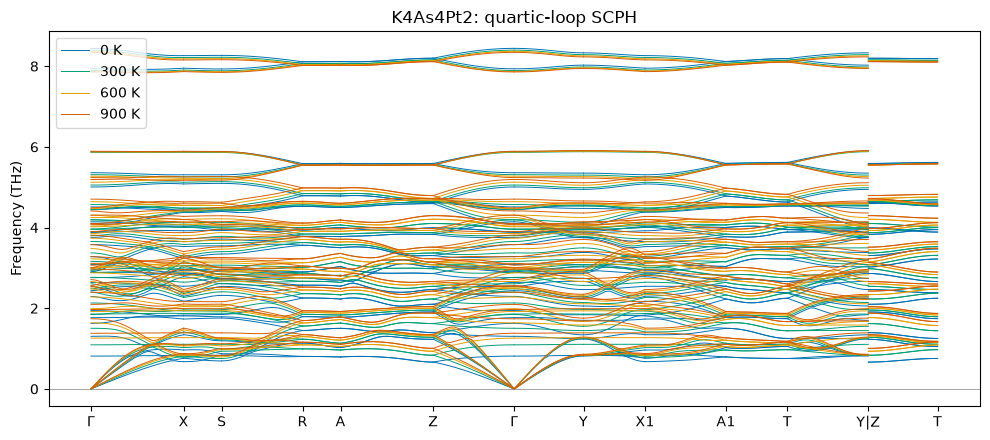

In [8]:
path = primitive.cell.bandpath(npoints=200)
fig, axis = plt.subplots(figsize=(10, 4.5))
for result, color in zip(results, ("#0072B2", "#009E73", "#E69F00", "#D55E00")):
    bands = Harmonic(result.fc2).run_band_path(path)
    for index, segment in enumerate(bands.segments):
        lines = axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color=color, lw=0.7)
        if index == 0:
            lines[0].set_label(f"{result.temperature:g} K")
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.axhline(0, color="0.5", lw=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("K4As4Pt2: quartic-loop SCPH")
axis.legend()
fig.tight_layout()
plt.show()

## 接下来

同一份联合拟合模型提供了两条结果：FC2、FC3 用于固定模型的 RTA 输运，FC2、FC4 用于四阶环近似的温度重整化。二者没有在本例中合成一个温度相关输运方案。

换材料时首先修改参考结构、训练数据、各阶截断与体阶，再选择输运网格、SCPH 网格和温度范围。若将热采样拟合得到的有效 FC2 当作 SCPH 裸项，还需评估是否重复计入温度效应。

继续阅读 [SCPH 接口](../scph.md)与[自洽声子理论](../theory/advanced/self-consistent-phonons.md)，或回到[教程总览](index.md)选择适合自己数据来源的流程。